In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.config import config_params
from src.field_data_processor import FieldDataProcessor
field_df = FieldDataProcessor(config_params).process()

2026-08-16 14:52:11 | src.data_ingestion | INFO | Starting data ingestion
2026-08-16 14:52:11 | src.field_data_processor | INFO | FieldDataProcessor is initialized
2026-08-16 14:52:11 | src.data_ingestion | INFO | Successfully connected to sqlite:///data/Maji_Ndogo_farm_survey_small.db
2026-08-16 14:52:12 | src.data_ingestion | INFO | Query executed successfully. Rows: 5654
2026-08-16 14:52:12 | src.field_data_processor | INFO | SQL data is successfully loaded into the pandas DataFrame
2026-08-16 14:52:12 | src.field_data_processor | INFO | Swapped columns: Annual_yield with Crop_type
2026-08-16 14:52:12 | src.field_data_processor | INFO | Converted the negative elavtion values to absulte figures.
2026-08-16 14:52:12 | src.field_data_processor | INFO | Mispelled crop names and extra spaces were found and got fixed
2026-08-16 14:52:12 | src.data_ingestion | INFO | Attempting to read CSV from: https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Maji_Ndogo/Weather_data_field_m

# 1: Sanity Check

In [3]:
field_df.head()

,Elevation,Latitude,Longitude,Location,Slope,Rainfall,Min_temperature_C,Max_temperature_C,Ave_temps,Soil_fertility,Soil_type,pH,Pollution_level,Plot_size,Annual_yield,Crop_type,Standard_yield
0,786.05580,-7.389911,-7.556202,Rural_Akatsi,14.795113,1125.2,-3.1,33.1,15.00,0.62,Sandy,6.169393,0.085267,1.3,0.751354,cassava,0.577964
1,674.33410,-7.736849,-1.051539,Rural_Sokoto,11.374611,1450.7,-3.9,30.6,13.35,0.64,Volcanic,5.676648,0.399684,2.2,1.069865,cassava,0.486302
2,826.53390,-9.926616,0.115156,Rural_Sokoto,11.339692,2208.9,-1.8,28.4,13.30,0.69,Volcanic,5.331993,0.358029,3.4,2.208801,tea,0.649647
3,574.94617,-2.420131,-6.592215,Rural_Kilimani,7.109855,328.8,-5.8,32.2,13.20,0.54,Loamy,5.328150,0.286687,2.4,1.277635,cassava,0.532348
4,886.35300,-3.055434,-7.952609,Rural_Kilimani,55.007656,785.2,-2.5,31.0,14.25,0.72,Sandy,5.721234,0.043190,1.5,0.832614,wheat,0.555076


In [4]:
field_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5654 entries, 0 to 5653
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Elevation          5654 non-null   float64
 1   Latitude           5654 non-null   float64
 2   Longitude          5654 non-null   float64
 3   Location           5654 non-null   str    
 4   Slope              5654 non-null   float64
 5   Rainfall           5654 non-null   float64
 6   Min_temperature_C  5654 non-null   float64
 7   Max_temperature_C  5654 non-null   float64
 8   Ave_temps          5654 non-null   float64
 9   Soil_fertility     5654 non-null   float64
 10  Soil_type          5654 non-null   str    
 11  pH                 5654 non-null   float64
 12  Pollution_level    5654 non-null   float64
 13  Plot_size          5654 non-null   float64
 14  Annual_yield       5654 non-null   float64
 15  Crop_type          5654 non-null   str    
 16  Standard_yield     5654 non-null   

In [5]:
field_df.shape

(5654, 17)

In [6]:
field_df.isnull().sum()

Elevation            0
Latitude             0
Longitude            0
Location             0
Slope                0
Rainfall             0
Min_temperature_C    0
Max_temperature_C    0
Ave_temps            0
Soil_fertility       0
Soil_type            0
pH                   0
Pollution_level      0
Plot_size            0
Annual_yield         0
Crop_type            0
Standard_yield       0
dtype: int64

In [7]:
field_df.duplicated().sum()

np.int64(0)

In [8]:
#Standard yield is the target variable. 
#check the distribution of the target variable.
round(field_df['Standard_yield'].describe().T, 4)

count    5654.0000
mean        0.5344
std         0.1118
min         0.1707
25%         0.4604
50%         0.5288
75%         0.5999
max         0.8980
Name: Standard_yield, dtype: float64

**The dataset is ready for exploratory analysis because the initial data-quality checks found no missing values or duplicate observations, the feature dtypes are appropriate for their intended use, and identifier fields that do not represent agricultural characteristics have been removed. Summary statistics also showed no immediately apparent structural anomalies requiring correction before EDA.**

# 2: Numerical Analysis

### 2: Univariate Analysis

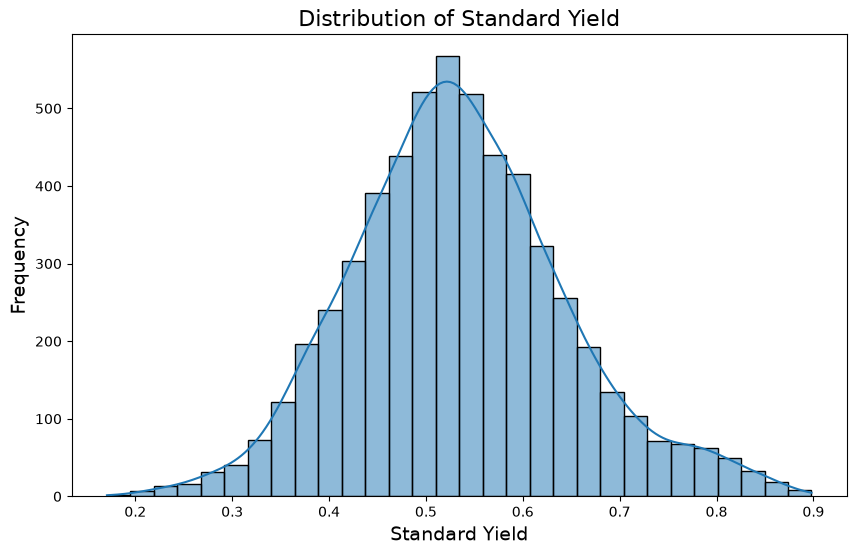

In [9]:
def plot_standard_yield_distribution(field_df):
    plt.figure(figsize=(10, 6))
    sns.histplot(data=field_df, x='Standard_yield', bins=30, kde=True)
    plt.title('Distribution of Standard Yield', fontsize=16)
    plt.xlabel('Standard Yield', fontsize=14)   
    plt.ylabel('Frequency', fontsize=14)
    plt.show()
plot_standard_yield_distribution(field_df)

The **Standard_yield** feature is approximately normally distributed wit a roughly symmetric bell-shapped distribution centred around 0.5 and only slight left skewness

### 3: Multivariate Analysis

In [10]:
numerical_features = field_df.select_dtypes(include=[float, int]).columns.tolist()
target_feature = field_df["Standard_yield"]
display(numerical_features)

['Elevation',
 'Latitude',
 'Longitude',
 'Slope',
 'Rainfall',
 'Min_temperature_C',
 'Max_temperature_C',
 'Ave_temps',
 'Soil_fertility',
 'pH',
 'Pollution_level',
 'Plot_size',
 'Annual_yield',
 'Standard_yield']

In [11]:
def correlation(field_df, numerical_features, target_feature)-> pd.DataFrame:
    correlation_df = field_df[numerical_features].corrwith(target_feature)
    correlation_df = round(correlation_df, 4).abs().sort_values(ascending=False)
    correlation_df = pd.DataFrame(correlation_df, columns=["correlation"])
    return correlation_df
correlation(field_df, numerical_features, target_feature)

,correlation
Standard_yield,1.0000
Pollution_level,0.2858
Annual_yield,0.2208
pH,0.1966
Min_temperature_C,0.1442
Elevation,0.1292
Max_temperature_C,0.1116
Longitude,0.0853
Soil_fertility,0.0702
Latitude,0.0617


In [12]:
def pearson_spearman(field_df, numerical_features)-> pd.DataFrame:
    pearson = round(field_df[numerical_features].corrwith(target_feature, method = "pearson"), 4)
    spearman = round(field_df[numerical_features].corrwith(target_feature, method = "spearman"), 4)
    correlation_df = pd.DataFrame({"pearson": pearson, "spearman": spearman})
    return correlation_df
pearson_spearman(field_df, numerical_features)


,pearson,spearman
Elevation,0.1292,0.1156
Latitude,0.0617,0.1057
Longitude,0.0853,0.0700
Slope,0.0570,0.0494
Rainfall,0.0392,-0.0397
Min_temperature_C,0.1442,0.1261
Max_temperature_C,-0.1116,-0.1134
Ave_temps,0.0068,-0.0129
Soil_fertility,0.0702,0.0011
pH,-0.1966,-0.1391


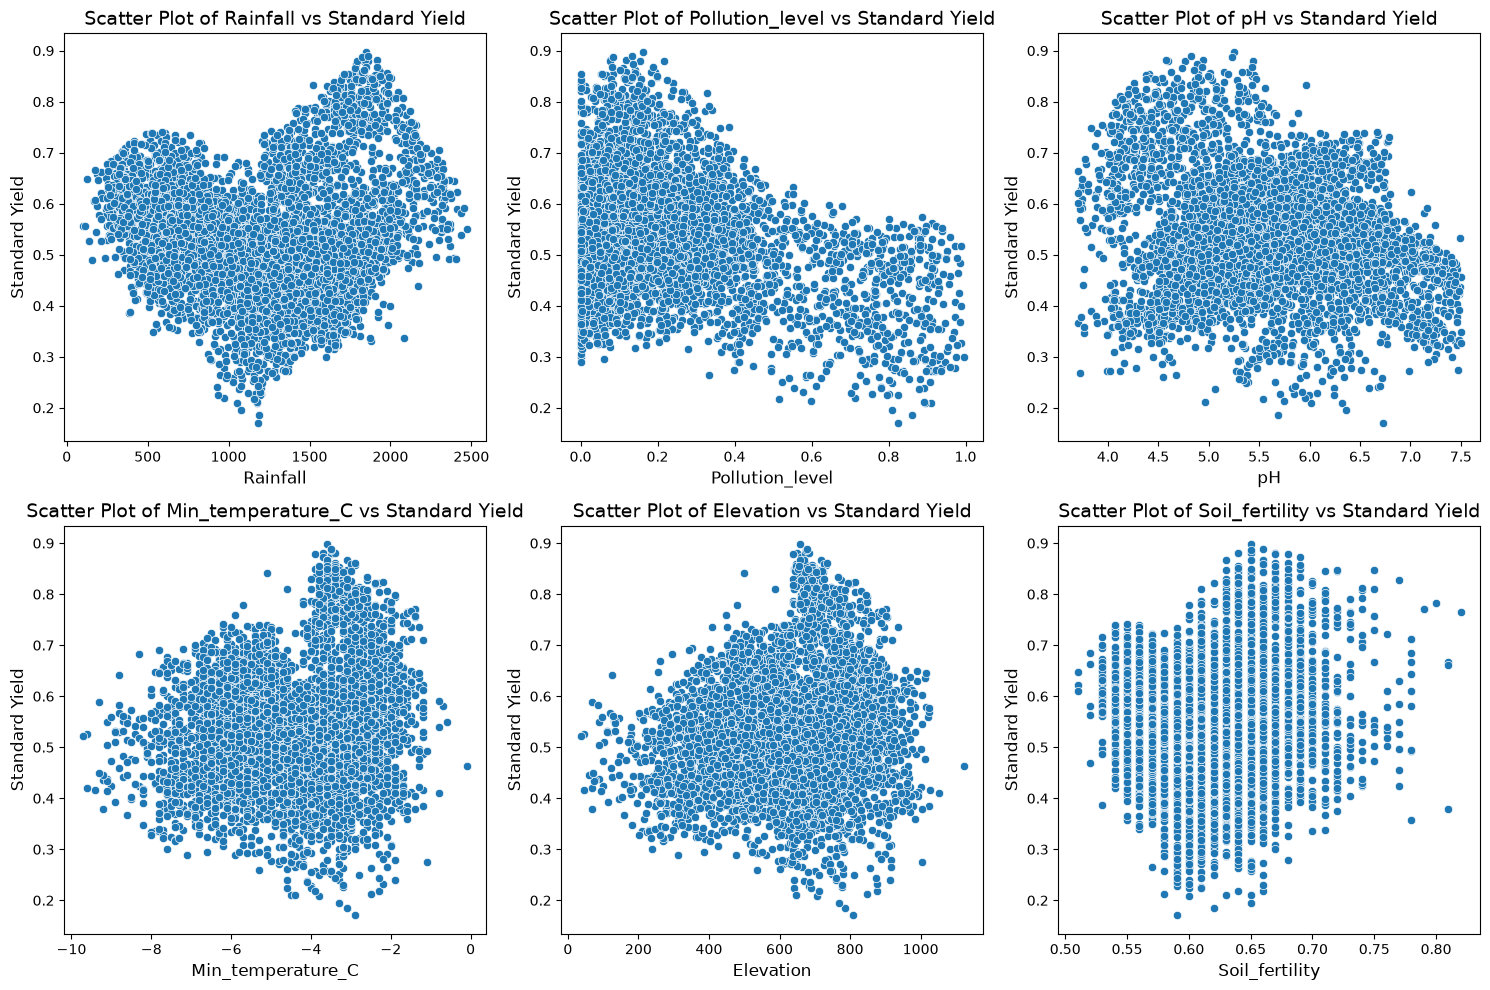

In [13]:
scatter_features = [
    "Rainfall",
    "Pollution_level",
    "pH",
    "Min_temperature_C",
    "Elevation",
    "Soil_fertility",
]

def scatter_plot(field_df, scatter_features, target_feature) ->plt.figure:
    plt.figure(figsize=(15, 10))
    for i, feature in enumerate(scatter_features):
        plt.subplot(2, 3, i + 1)
        sns.scatterplot(data=field_df, x=feature, y=target_feature)
        plt.title(f'Scatter Plot of {feature} vs Standard Yield', fontsize=14)
        plt.xlabel(feature, fontsize=12)
        plt.ylabel('Standard Yield', fontsize=12)
    plt.tight_layout()
    plt.show()
scatter_plot(field_df, scatter_features, target_feature)

The scatter plots and correlation analysis indicate that Standard_yield has generally weak linear associations with the numerical predictors. Pollution_level shows the strongest negative Pearson correlation (r = −0.286), followed by pH (r = −0.197), while Min_temperature_C (r = 0.144) and Elevation (r = 0.129) show weak positive associations. Rainfall and Soil_fertility exhibit very weak linear and/or monotonic correlations despite patterns visible in their scatter plots, suggesting that their relationships with yield may not be adequately captured by linear or monotonic correlation measures. 

Overall, no single numerical predictor shows a strong marginal association with Standard_yield, suggesting that yield may depend on nonlinear relationships, interactions, and combinations of multiple environmental and agricultural factors.

# 3: Categorical Analysis

In [14]:
field_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5654 entries, 0 to 5653
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Elevation          5654 non-null   float64
 1   Latitude           5654 non-null   float64
 2   Longitude          5654 non-null   float64
 3   Location           5654 non-null   str    
 4   Slope              5654 non-null   float64
 5   Rainfall           5654 non-null   float64
 6   Min_temperature_C  5654 non-null   float64
 7   Max_temperature_C  5654 non-null   float64
 8   Ave_temps          5654 non-null   float64
 9   Soil_fertility     5654 non-null   float64
 10  Soil_type          5654 non-null   str    
 11  pH                 5654 non-null   float64
 12  Pollution_level    5654 non-null   float64
 13  Plot_size          5654 non-null   float64
 14  Annual_yield       5654 non-null   float64
 15  Crop_type          5654 non-null   str    
 16  Standard_yield     5654 non-null   

In [15]:
categorical_features = field_df.select_dtypes(include=["str"]).columns.tolist()
display(categorical_features)

['Location', 'Soil_type', 'Crop_type']

In [20]:
crop_type = round(field_df.groupby("Crop_type")["Standard_yield"].
                  agg(["sum", "mean", "count","min", "max", "median", "std"])
                  .sort_values(by="mean", ascending=False), 4)
crop_type

,sum,mean,count,min,max,median,std
Crop_type,,,,,,,
tea,588.5966,0.6447,913,0.2744,0.8980,0.6656,0.1360
rice,155.5192,0.5869,265,0.4035,0.8330,0.5881,0.0742
potato,478.9339,0.5819,823,0.4218,0.6995,0.5862,0.0516
maize,211.9164,0.5311,399,0.3395,0.7119,0.5247,0.0782
wheatn,6.8400,0.5262,13,0.3833,0.6769,0.5232,0.0721
wheat,685.4771,0.5158,1329,0.2114,0.7411,0.5127,0.0895
cassava,320.9263,0.4776,672,0.2676,0.6600,0.4833,0.0777
coffee,280.9015,0.4628,607,0.1707,0.6996,0.4797,0.1006
banana,292.4156,0.4620,633,0.2604,0.6700,0.4532,0.0804


In [17]:
soil_type = [round(field_df.groupby("Soil_type")["Standard_yield"]
                   .agg(["sum", "mean", "count", "min", "max", "median", "std"])
                   .sort_values(by="mean", ascending=False), 4)]
soil_type

[                sum    mean  count     min     max  median     std
 Soil_type                                                         
 Volcanic   793.3086  0.5969   1329  0.2489  0.8980  0.5958  0.1433
 Loamy      564.2290  0.5799    973  0.2717  0.7411  0.5951  0.0898
 Sandy      788.7111  0.5046   1563  0.1707  0.6545  0.5180  0.0839
 Rocky      151.2878  0.4977    304  0.2133  0.6466  0.5042  0.0859
 Silt       647.7686  0.4926   1315  0.2604  0.8422  0.4934  0.0772
 Peaty       76.2214  0.4484    170  0.2603  0.8100  0.4122  0.1067]

In [21]:
location = round(field_df.groupby("Location")["Standard_yield"]
                 .agg(["sum", "mean", "count","min", "max", "median", "std"])
                 .sort_values(by="mean", ascending=False), 4)
location

,sum,mean,count,min,max,median,std
Location,,,,,,,
Rural_Sokoto,537.8562,0.5885,914,0.2603,0.8980,0.5757,0.1527
Rural_Kilimani,1075.0221,0.5322,2020,0.1707,0.7411,0.5445,0.0993
Rural_Akatsi,380.0574,0.5228,727,0.2956,0.8792,0.5140,0.0962
Rural_Amanzi,134.1756,0.5181,259,0.3180,0.7233,0.5264,0.0770
Rural_Hawassa,894.4152,0.5158,1734,0.2186,0.8579,0.5085,0.1013


Categorical analysis reveals substantial differences in the observed distribution of Standard_yield across crop types, soil types, and locations. Tea has the highest mean yield among crop types, while volcanic soil has the highest mean among soil categories. However, these are descriptive, unadjusted comparisons and may reflect differences in environmental conditions and group composition.These findings suggest that categorical variables may provide useful predictive information, but their effects should be evaluated alongside environmental variables in the multivariate modelling stage.

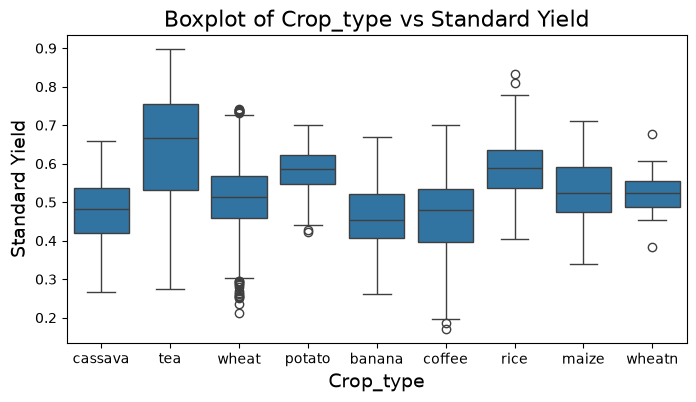

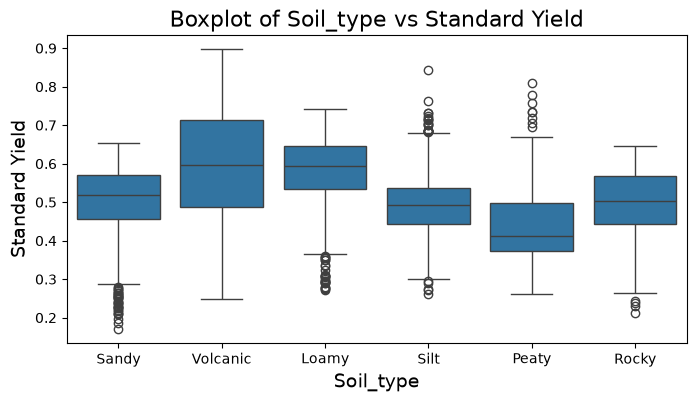

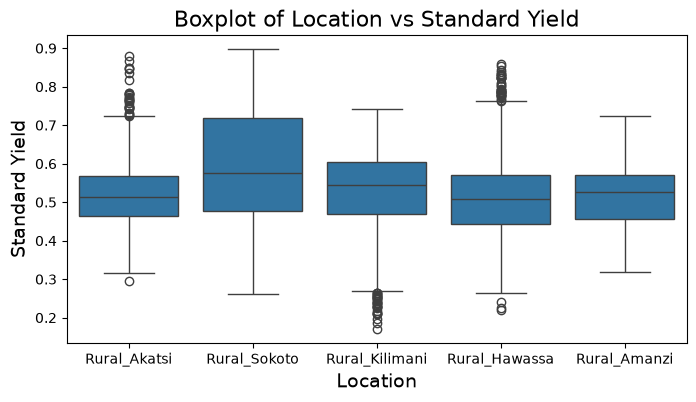

In [19]:
categorical_features = ["Crop_type", "Soil_type", "Location"]

for feature in categorical_features:
    plt.figure(figsize = (8, 4))
    sns.boxplot(data=field_df, x = feature, y = target_feature)
    plt.title(f'Boxplot of {feature} vs Standard Yield', fontsize=16)
    plt.xlabel(feature, fontsize=14)
    plt.ylabel('Standard Yield', fontsize=14)
    plt.show()

Boxplot analysis shows substantial differences in the distribution of Standard_yield across crop types, soil types, and locations. 
Tea, volcanic soil, and Rural_Sokoto exhibit the highest median yields, while banana, peaty soil, and Rural_Hawassa exhibit the lowest. Tea, volcanic soil, and Rural_Sokoto also show relatively large interquartile ranges, indicating greater variability within these groups. 

Several categories contain observations beyond the whiskers, particularly Rural_Akatsi, wheat and silt; these observations will be treated as potential extreme values rather than automatically removed, since they may represent legitimate variation in agricultural conditions.